In [13]:
from dolfin import *
import numpy as np
import matplotlib.pyplot as plt
from fenics import project
import torch
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
import os
import argparse
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import imageio
from beam_fea_solver import compute_von_mises_3d
from pathlib import Path
from dataclasses import dataclass, asdict

ModuleNotFoundError: No module named 'dolfin'

In [ ]:
@dataclass
class Stats:
    mean: torch.Tensor
    std: torch.Tensor

In [ ]:
dt = 0.08

In [ ]:
from pathlib import Path

data_dir = Path("Results/train/graphs")
filenames = list(data_dir.glob("*.pt"))

train_graphs = []
categorical_node_features = []
valued_node_features = []
edge_features = []
targets = []
for idx, filename in enumerate(filenames):
    dataloader = torch.load(filename, weights_only=False)
    for data in dataloader:
        graph = data.to("cpu")
        graphs.append(graph)
    for graph in graphs:
        boundary_condition = graph.x_bc  # 1 fixed, 0 free
        node_force = graph.x_node_force  # external force on node
        x = graph.x

        categorical_node_features.append(boundary_condition)
        valued_node_features.append(torch.concat([x, graph.x_vel_t, node_force], dim=1))
        train_graphs.append(Data(edge_index=graph.edge_index))

        src, dst = graph.edge_index
        xij = x[dst] - x[src]
        xij_norm = torch.norm(xij, dim=1).unsqueeze(1)
        edge_features.append(torch.concat([xij, xij_norm], dim=1))

        von_mises = compute_von_mises_3d(graph.y_sig_t).unsqueeze(1)
        targets.append(torch.concat([graph.y_acc_t, von_mises], dim=1))


def compute_stats(tensor_list) -> Stats:
    # would also be an option to batch over all tensors
    # Batch.from_data_list(train_graphs).x.mean(dim=0)
    # but this uses less memory

    sum = 0
    sum_sq = 0
    count = 0
    for tensor in tensor_list:
        sum += tensor.sum(dim=0)
        sum_sq += (tensor**2).sum(dim=0)
        count += tensor.shape[0]
    mean = sum / count
    var = (sum_sq / count) - (mean**2)
    std = torch.sqrt(var)
    return Stats(mean=mean, std=std)


def normalize(tensor: torch.Tensor, stats: Stats, eps: float = 1e-8) -> torch.Tensor:
    return (tensor - stats.mean) / (stats.std + eps)


def denormalize(tensor: torch.Tensor, stats: Stats, eps: float = 1e-8) -> torch.Tensor:
    return tensor * (stats.std + eps) + stats.mean


node_stats = compute_stats(valued_node_features)
edge_stats = compute_stats(edge_features)
target_stats = compute_stats(targets)

stats = {
    "node": asdict(node_stats),
    "edge": asdict(edge_stats),
    "target": asdict(target_stats),
}
print(stats)

for i in range(len(train_graphs)):
    _valued_node_features = normalize(valued_node_features[i], node_stats)
    _edge_features = normalize(edge_features[i], edge_stats)
    _targets = normalize(targets[i], target_stats)
    train_graphs[i].x = torch.concat(
        [categorical_node_features[i], _valued_node_features], dim=1
    )
    train_graphs[i].edge_attr = _edge_features
    train_graphs[i].y = _targets

{'node': {'mean': tensor([ 5.6398e-01,  6.2386e-02,  2.7890e-02,  1.6197e-05,  2.6936e-02,
        -4.5063e-04,  0.0000e+00,  1.1443e-02,  0.0000e+00]), 'std': tensor([0.4983, 0.1251, 0.0296, 0.0341, 0.4679, 0.0443, 0.0000, 0.1116, 0.0000])}, 'edge': {'mean': tensor([ 1.8892e-11, -1.6603e-11,  1.5711e-11,  7.2351e-02]), 'std': tensor([0.1439, 0.0254, 0.0123, 0.1275])}, 'target': {'mean': tensor([-6.9054e-06,  1.8023e-03, -5.2576e-03,  8.4858e+00]), 'std': tensor([ 0.1788,  2.0332,  0.1718, 12.3043])}}


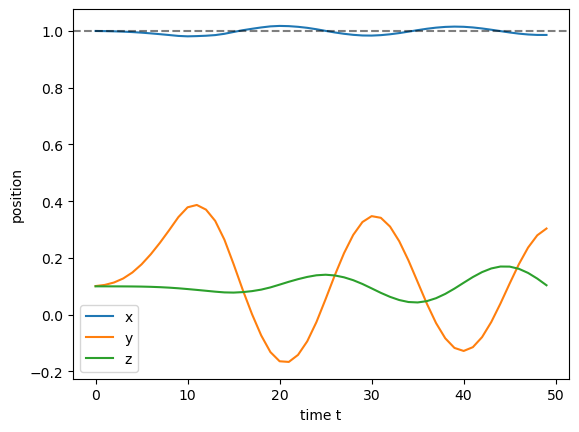

In [ ]:
traj = []
for graph in graphs:
    traj.append(graph.x[-1])
traj = torch.stack(traj).numpy()
plt.plot(traj[:, 0], label="x")
plt.plot(traj[:, 1], label="y")
plt.plot(traj[:, 2], label="z")
plt.axhline(1, color="k", alpha=0.5, linestyle="--")
plt.legend()
plt.xlabel("time t")
plt.ylabel("position")
plt.show()


In [ ]:
default_params = {
    "L": 1.0,
    "W": 0.1,
    "D": 0.1,
    "NL": 4,
    "NW": 2,
    "ND": 2,
    "E": 1000.0,
    "nu": 0.3,
    "rho": 1.0,
    "eta_m": 0.01,
    "eta_k": 0.01,
    "alpha_m": 0.0,
    "alpha_f": 0.0,
    "total_time": 4.0,
    "cutoff_time_factor": 0.2,
    "num_steps": 50,
}

forces = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
cutoff_time_factors = [0.1, 0.2, 0.3]
lengths = [0.5, 0.75, 1.0]
widths = [0.05, 0.1]
depths = [0.05, 0.1]
from itertools import product

param_combinations = list(product(forces, lengths, widths))
for idx, (initial_force, L, W) in enumerate(param_combinations):
    print(f"\n=== Simulation Set {idx + 1} ===")
    params = default_params.copy()
    params.update(
        {
            "initial_force": initial_force,
            "L": L,
            "W": W,
            "mode": "train",
        }
    )
    print((initial_force, L, W))



=== Simulation Set 1 ===
(0.25, 0.5, 0.05)

=== Simulation Set 2 ===
(0.25, 0.5, 0.1)

=== Simulation Set 3 ===
(0.25, 0.75, 0.05)

=== Simulation Set 4 ===
(0.25, 0.75, 0.1)

=== Simulation Set 5 ===
(0.25, 1.0, 0.05)

=== Simulation Set 6 ===
(0.25, 1.0, 0.1)

=== Simulation Set 7 ===
(0.5, 0.5, 0.05)

=== Simulation Set 8 ===
(0.5, 0.5, 0.1)

=== Simulation Set 9 ===
(0.5, 0.75, 0.05)

=== Simulation Set 10 ===
(0.5, 0.75, 0.1)

=== Simulation Set 11 ===
(0.5, 1.0, 0.05)

=== Simulation Set 12 ===
(0.5, 1.0, 0.1)

=== Simulation Set 13 ===
(0.75, 0.5, 0.05)

=== Simulation Set 14 ===
(0.75, 0.5, 0.1)

=== Simulation Set 15 ===
(0.75, 0.75, 0.05)

=== Simulation Set 16 ===
(0.75, 0.75, 0.1)

=== Simulation Set 17 ===
(0.75, 1.0, 0.05)

=== Simulation Set 18 ===
(0.75, 1.0, 0.1)

=== Simulation Set 19 ===
(1.0, 0.5, 0.05)

=== Simulation Set 20 ===
(1.0, 0.5, 0.1)

=== Simulation Set 21 ===
(1.0, 0.75, 0.05)

=== Simulation Set 22 ===
(1.0, 0.75, 0.1)

=== Simulation Set 23 ===
(1.0,

In [ ]:
import torch

data = torch.load("dataset/beam/val/graph_00.pt", weights_only=False)

In [ ]:
from pathlib import Path

results_dir = Path("Results/train/graphs")
results_large_dir = Path("Results_large/train/graphs")

print(f"Samples in results_dir: {len(list(results_dir.glob('*.pt')))}")
print(f"Samples in results_large_dir: {len(list(results_large_dir.glob('*.pt')))}")

Samples in results_dir: 54
Samples in results_large_dir: 216


In [ ]:
d0 = data[0]
d1 = data[1]

In [ ]:
d0

Data(x=[225, 10], edge_index=[2, 2304], edge_attr=[2304, 4], t=[1], x_pos_t=[225, 3], x_vel_t=[225, 3], node_force=[225, 3], node_force_next=[225, 3], x_next=[225, 3], v_next=[225, 3], y_acc_t=[225, 3], y_von_mises=[225, 1], x_element_connectivity=[1])

In [ ]:
x, v, a = d0.x_pos_t, d0.x_vel_t, d0.y_acc_t
x_next, v_next = d1.x_pos_t, d1.x_vel_t
dt = 0.08

In [ ]:
v_new = v + a * dt
x_new = x + (v + v_new) * dt * 0.5
print(x_new[:6], v_next[:6])
print(x_next[:6], v_next[:6])


tensor([[ 1.4717e-21, -5.9780e-22,  1.5283e-22],
        [ 1.1252e-01, -8.7038e-06,  2.0739e-06],
        [ 2.2507e-01,  4.6647e-05,  4.8729e-06],
        [ 3.3764e-01,  2.1779e-04,  7.7233e-06],
        [ 4.5024e-01,  5.5538e-04,  9.5354e-06],
        [ 5.6286e-01,  1.1046e-03,  9.0426e-06]]) tensor([[7.7881e-20, 6.6629e-20, 3.6090e-21],
        [1.0520e-03, 9.4517e-04, 4.8638e-05],
        [2.2001e-03, 3.9196e-03, 7.3902e-05],
        [3.3874e-03, 9.1499e-03, 8.8115e-05],
        [4.5398e-03, 1.6665e-02, 7.9574e-05],
        [5.5631e-03, 2.6327e-02, 3.9870e-05]])
tensor([[3.7039e-21, 2.4261e-21, 2.0549e-22],
        [1.1255e-01, 3.4325e-05, 2.7751e-06],
        [2.2511e-01, 1.7544e-04, 4.9052e-06],
        [3.3769e-01, 4.5311e-04, 6.6139e-06],
        [4.5028e-01, 8.8874e-04, 6.9971e-06],
        [5.6286e-01, 1.4949e-03, 5.2118e-06]]) tensor([[7.7881e-20, 6.6629e-20, 3.6090e-21],
        [1.0520e-03, 9.4517e-04, 4.8638e-05],
        [2.2001e-03, 3.9196e-03, 7.3902e-05],
        [3.38

In [14]:
from torch_geometric.data import Data, Batch
import matplotlib.pyplot as plt

b = Batch.from_data_list(data)
plt.hist(b.y_acc_t.flatten(), bins=50)

NameError: name 'data' is not defined

In [ ]:
import torch
from torch import Tensor


def calculate_kinematics(x: Tensor, dt: float) -> tuple[Tensor, Tensor]:
    v0 = torch.zeros(1, x.shape[1], device=x.device, dtype=x.dtype)

    dx = x[1:] - x[:-1]
    v_steps = dx / dt

    v = torch.cat([v0, v_steps], dim=0)

    dv = v[1:] - v[:-1]
    a = dv / dt

    return v, a

In [ ]:
# Create a dummy trajectory: A particle accelerating from 0,0,0
T, dt = 10, 0.1
# Example: x = 0.5 * a * t^2 (Constant acceleration of 4.0)
t = torch.linspace(0, (T - 1) * dt, T).unsqueeze(1)
true_accel = torch.linspace(0.1, 2.7, T)
true_v0 = torch.ones(1, 1) * 2.0

x_traj = true_v0 * t + 0.5 * true_accel.unsqueeze(1) * t**2
x_traj = torch.cat([x_traj, torch.zeros(T, 2)], dim=1)  # Make it 3D (x movement only)

x_true = x_traj
v_true = torch.cat([true_v0 + true_accel.unsqueeze(1) * t, torch.zeros(T, 2)], dim=1)
a_true = true_accel.unsqueeze(1).repeat(1, 3)

In [ ]:
x_true, v_true, a_true

(tensor([[0.0000, 0.0000, 0.0000],
         [0.2019, 0.0000, 0.0000],
         [0.4136, 0.0000, 0.0000],
         [0.6435, 0.0000, 0.0000],
         [0.9004, 0.0000, 0.0000],
         [1.1931, 0.0000, 0.0000],
         [1.5300, 0.0000, 0.0000],
         [1.9199, 0.0000, 0.0000],
         [2.3716, 0.0000, 0.0000],
         [2.8935, 0.0000, 0.0000]]),
 tensor([[2.0000, 0.0000, 0.0000],
         [2.0389, 0.0000, 0.0000],
         [2.1356, 0.0000, 0.0000],
         [2.2900, 0.0000, 0.0000],
         [2.5022, 0.0000, 0.0000],
         [2.7722, 0.0000, 0.0000],
         [3.1000, 0.0000, 0.0000],
         [3.4856, 0.0000, 0.0000],
         [3.9289, 0.0000, 0.0000],
         [4.4300, 0.0000, 0.0000]]),
 tensor([[0.1000, 0.1000, 0.1000],
         [0.3889, 0.3889, 0.3889],
         [0.6778, 0.6778, 0.6778],
         [0.9667, 0.9667, 0.9667],
         [1.2556, 1.2556, 1.2556],
         [1.5444, 1.5444, 1.5444],
         [1.8333, 1.8333, 1.8333],
         [2.1222, 2.1222, 2.1222],
         [2.4111

In [ ]:
v_calc, a_calc, x_recon

(tensor([[0.0000, 0.0000, 0.0000],
         [2.0194, 0.0000, 0.0000],
         [2.1161, 0.0000, 0.0000],
         [2.2994, 0.0000, 0.0000],
         [2.5694, 0.0000, 0.0000],
         [2.9261, 0.0000, 0.0000],
         [3.3694, 0.0000, 0.0000],
         [3.8994, 0.0000, 0.0000],
         [4.5161, 0.0000, 0.0000],
         [5.2194, 0.0000, 0.0000]]),
 tensor([[20.1944,  0.0000,  0.0000],
         [ 0.9667,  0.0000,  0.0000],
         [ 1.8333,  0.0000,  0.0000],
         [ 2.7000,  0.0000,  0.0000],
         [ 3.5667,  0.0000,  0.0000],
         [ 4.4333,  0.0000,  0.0000],
         [ 5.3000,  0.0000,  0.0000],
         [ 6.1667,  0.0000,  0.0000],
         [ 7.0334,  0.0000,  0.0000]]),
 tensor([[0.0000, 0.0000, 0.0000],
         [0.2019, 0.0000, 0.0000],
         [0.4136, 0.0000, 0.0000],
         [0.6435, 0.0000, 0.0000],
         [0.9004, 0.0000, 0.0000],
         [1.1931, 0.0000, 0.0000],
         [1.5300, 0.0000, 0.0000],
         [1.9199, 0.0000, 0.0000],
         [2.3716, 0.0000

In [ ]:
# Calculate
v_calc, a_calc = calculate_kinematics(x_traj, dt)

print(f"Shape of x: {x_traj.shape}")  # (10, 3)
print(f"Shape of v: {v_calc.shape}")  # (10, 3)
print(f"Shape of a: {a_calc.shape}")  # (9, 3)

print(f"\nCalculated a[0] (should be close to {true_accel}):\n{a_calc[0]}")

# --- Verification Rollout ---
# Reconstruct x using the calculated a and v[0]
x_recon = torch.zeros_like(x_traj)
v_recon = torch.zeros_like(v_calc)

x_recon[0] = x_traj[0]
v_recon[0] = v_calc[0]  # 0

for i in range(len(a_calc)):
    # Semi-Implicit Euler
    v_recon[i + 1] = v_recon[i] + a_calc[i] * dt
    x_recon[i + 1] = x_recon[i] + v_recon[i + 1] * dt

error = torch.mean((x_traj - x_recon) ** 2)
print(f"\nReconstruction MSE Loss: {error.item():.6f}")

Shape of x: torch.Size([10, 3])
Shape of v: torch.Size([10, 3])
Shape of a: torch.Size([9, 3])

Calculated a[0] (should be close to tensor([0.1000, 0.3889, 0.6778, 0.9667, 1.2556, 1.5444, 1.8333, 2.1222, 2.4111,
        2.7000])):
tensor([20.1944,  0.0000,  0.0000])

Reconstruction MSE Loss: 0.000000


In [10]:
from in_memory_dataset import InMemoryTimeStepDataset
from torch_geometric.loader import DataLoader

train_dataset = InMemoryTimeStepDataset(sample_dir="dataset/beam/val")
train_loader = DataLoader(train_dataset, batch_size=9999, shuffle=True)
for item in train_loader:
    data = item

Found 1 sample files
Loaded the dataset with 49 samples


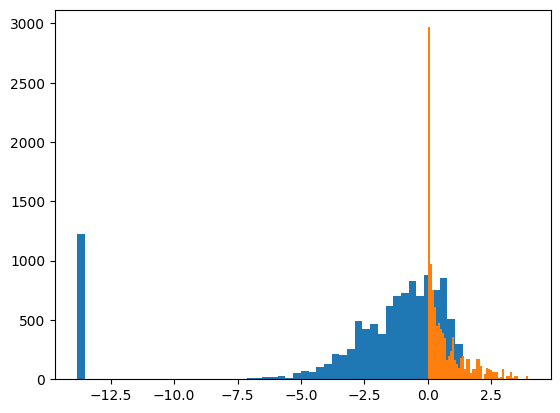

In [ ]:
a = data.y_acc_t.numpy()
anorms = np.linalg.norm(a, axis=1)
_ = plt.hist(np.log(anorms + 1e-6), bins=50)

_ = plt.hist(anorms, bins=50)

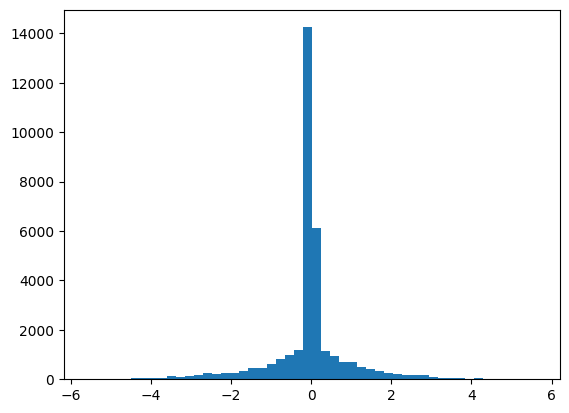

In [ ]:
a_unit = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-8)
a_new = a_unit * np.log(anorms + 1e-6).reshape(-1, 1)
_ = plt.hist(a_new.flatten(), bins=50)

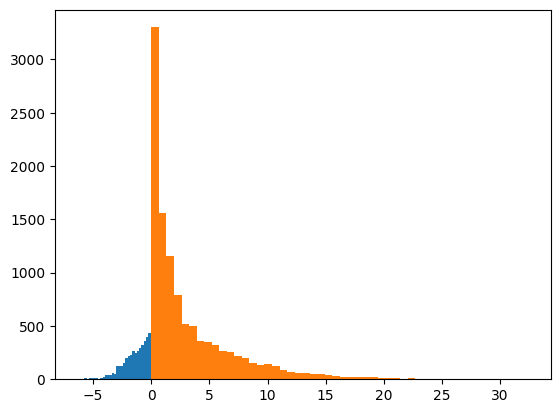

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

vm = data.y_von_mises.flatten()
_ = plt.hist(vm.numpy(), bins=50)
_ = plt.hist(np.exp(vm.numpy() + 1e-6), bins=50)